# 📦 ParcelCast — Notebook 2
## Modeling: Baseline / Prophet / LightGBM

**What this notebook does:** Trains three forecasting models on the cleaned
weekly volumes from Notebook 1, evaluates them with the team's exact metrics
(Traditional Error + WMAPE), and produces a lag-analysis table mirroring the
WPR reporting format. Outputs a forecast parquet for the business notebook.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd().parent))

from src.evaluation import all_metrics, build_scorecard, lag_analysis
from src.features import build_feature_set, get_feature_columns, get_feature_table
from src.models import LightGBMForecaster, MovingAverageBaseline, ProphetModel

sns.set_theme(style="whitegrid", palette="muted")
PRESENTATION_DIR = Path.cwd().parent / "presentation"
DATA_DIR = Path.cwd().parent / "data"

TEST_WEEKS = 12  # Hold out last 12 weeks for evaluation

## 1. Load cleaned data
Reads the per-(region, channel, week) parquet produced by Notebook 1.

In [2]:
weekly = pd.read_parquet(DATA_DIR / "weekly_region_channel.parquet")
weekly["week_start"] = pd.to_datetime(weekly["week_start"])
print(f"Loaded {len(weekly):,} rows")
weekly.head()

Loaded 1,662 rows


,region,channel,wm_yr_wk,week_start,units,upp,packages
0,WEST,1P,11101,2011-01-29,72459,2.100000,34504.285714
1,WEST,1P,11102,2011-02-05,76606,2.098774,36500.348456
2,WEST,1P,11103,2011-02-12,66480,2.097550,31694.124114
3,WEST,1P,11104,2011-02-19,64972,2.096326,30993.277037
4,WEST,1P,11105,2011-02-26,67064,2.095102,32009.893921


### Aggregate to network level + chronological train/test split
Three of our models forecast network total. We hold out the last 12 weeks
chronologically (no shuffling — that would leak future into past).

In [3]:
network = (
    weekly.groupby("week_start", as_index=False)
    .agg(packages=("packages", "sum"), upp=("upp", "mean"))
)
print(f"Network-level weeks: {len(network)}")

train = network.iloc[:-TEST_WEEKS].copy()
test = network.iloc[-TEST_WEEKS:].copy()
print(f"Train: {len(train)} weeks, Test: {len(test)} weeks")

Network-level weeks: 277
Train: 265 weeks, Test: 12 weeks


## 2. Baseline: 4-week moving average
Every more-complex model has to clear this floor to justify its complexity.
Without a baseline, "1.55% WMAPE" is a number with no anchor.

In [4]:
baseline = MovingAverageBaseline(window=4).fit(train, target_col="packages")
baseline_pred = baseline.predict(TEST_WEEKS)
baseline_metrics = all_metrics(test["packages"].values, baseline_pred)
print(f"Baseline metrics: {baseline_metrics}")

Baseline metrics: {'traditional_error_pct': np.float64(-1.86), 'wmape_pct': np.float64(3.96)}


## 3. Prophet with US retail holidays
Multiplicative seasonality because retail seasonal swings scale with the
level of the series (a 20% Black Friday lift in 2016 moves more units than
the same percentage lift in 2011). Holidays come pre-configured in `src/models.py`.

In [5]:
prophet = ProphetModel(seasonality_mode="multiplicative").fit(
    train, date_col="week_start", target_col="packages",
)
prophet_forecast = prophet.predict_with_intervals(TEST_WEEKS)
prophet_pred = prophet_forecast["yhat"].values
prophet_metrics = all_metrics(test["packages"].values, prophet_pred)
print(f"Prophet metrics: {prophet_metrics}")

05:36:59 - cmdstanpy - INFO - Chain [1] start processing


05:36:59 - cmdstanpy - INFO - Chain [1] done processing


Prophet metrics: {'traditional_error_pct': np.float64(-5.56), 'wmape_pct': np.float64(5.88)}


## 4. LightGBM (global model — all region × channel series)
A single model trained across all series with group identifiers as features.
This lets it learn cross-series patterns and use lag/calendar/UPP features
that Prophet structurally can't accept.

### Build the feature matrix
Adds lag features (1, 2, 4, 8, 12, 52), YoY growth, calendar features, and
lagged UPP. Bare `upp` is excluded — it's used in computing the target so
would leak.

In [6]:
featured = build_feature_set(weekly, target_col="packages")
feature_cols = [c for c in get_feature_columns(featured) if c not in {"upp"}]

# Train/test split — same date cutoff as Prophet
cutoff_date = train["week_start"].max()
lgbm_train = featured[featured["week_start"] <= cutoff_date]
lgbm_test = featured[featured["week_start"] > cutoff_date]

print(f"LightGBM train: {len(lgbm_train):,} rows, test: {len(lgbm_test):,} rows")
print(f"Features ({len(feature_cols)}): {feature_cols}")

LightGBM train: 1,590 rows, test: 72 rows
Features (18): ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_52', 'yoy_growth', 'year', 'month', 'quarter', 'fiscal_week', 'woy_sin', 'woy_cos', 'is_peak', 'is_bts', 'is_holiday', 'upp_lag_1', 'upp_lag_4']


### Fit and aggregate predictions to network level
LightGBM predicts per (region, channel) row; we sum to network total so all
three models can be compared on the same axis.

In [7]:
lgbm = LightGBMForecaster()
lgbm.fit(lgbm_train, feature_cols, target_col="packages", n_estimators=500)
lgbm_test_preds = lgbm.predict(lgbm_test)

# Aggregate to network-level for comparison with other models
lgbm_test_df = lgbm_test.copy()
lgbm_test_df["pred"] = lgbm_test_preds
lgbm_network_pred = lgbm_test_df.groupby("week_start")["pred"].sum().sort_index().values
lgbm_network_actual = lgbm_test_df.groupby("week_start")["packages"].sum().sort_index().values

lgbm_metrics = all_metrics(lgbm_network_actual, lgbm_network_pred)
print(f"LightGBM metrics: {lgbm_metrics}")

LightGBM metrics: {'traditional_error_pct': np.float64(-0.64), 'wmape_pct': np.float64(1.55)}


### Feature importance (LightGBM)

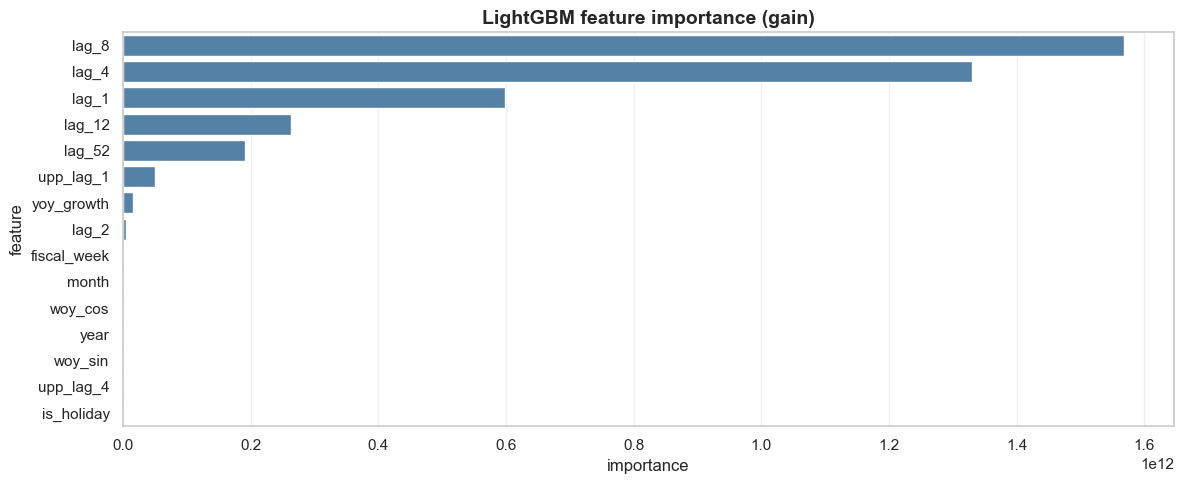

In [8]:
fi = lgbm.feature_importance(top_n=15)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=fi, x="importance", y="feature", ax=ax, color="steelblue")
ax.set_title("LightGBM feature importance (gain)",
             fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "04_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Model Scorecard
Compare all three models on the same test set with the same metrics.
WMAPE rank tells us which to ship; Traditional Error tells us the bias direction.

In [9]:
scorecard = build_scorecard(
    test["packages"].values,
    {
        "Baseline (4wk MA)": baseline_pred,
        "Prophet": prophet_pred,
        "LightGBM": lgbm_network_pred,
    },
)
scorecard

,model,traditional_error_pct,wmape_pct,rank_wmape
0,LightGBM,-0.64,1.55,1
1,Baseline (4wk MA),-1.86,3.96,2
2,Prophet,-5.56,5.88,3


### Persist the scorecard
The business notebook reads this CSV to render Panel 3 of the executive dashboard.

In [10]:
scorecard.to_csv(DATA_DIR / "model_scorecard.csv", index=False)

## 6. Forecast vs Actuals (visualization)

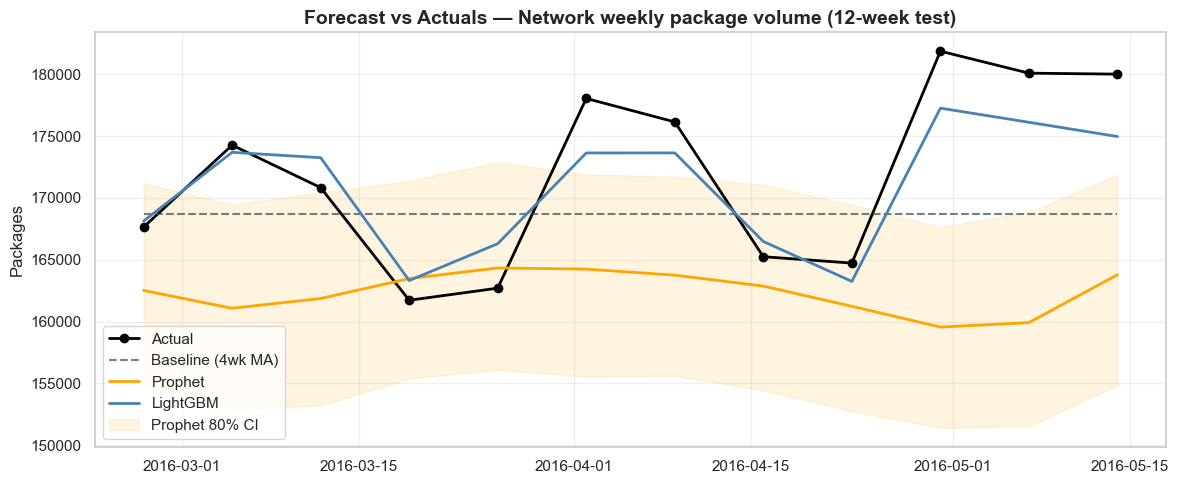

In [11]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test["week_start"], test["packages"], color="black",
        marker="o", label="Actual", linewidth=2)
ax.plot(test["week_start"], baseline_pred, "--",
        label="Baseline (4wk MA)", color="darkslategray", alpha=0.7)
ax.plot(test["week_start"], prophet_pred, "-",
        label="Prophet", color="orange", linewidth=2)
ax.plot(test["week_start"], lgbm_network_pred, "-",
        label="LightGBM", color="steelblue", linewidth=2)
ax.fill_between(
    test["week_start"],
    prophet_forecast["yhat_lower"].values,
    prophet_forecast["yhat_upper"].values,
    color="orange", alpha=0.12, label="Prophet 80% CI",
)
ax.set_title("Forecast vs Actuals — Network weekly package volume (12-week test)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Packages")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "05_forecast_vs_actuals.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Lag Analysis (mirrors WPR format)
Forecast accuracy at horizons 1–4 weeks. This matches the WPR reporting
format and shows the expected monotonic degradation as horizon extends.

### Define the rolling lag-N backtest
For each test week `t`, retrain the model on data ending `t − N` weeks earlier
and predict `t`. This simulates how the model would have performed under
a real `N`-week-ahead planning cadence.

In [12]:
def rolling_lag_forecast(series_df: pd.DataFrame, lag: int, n_test_weeks: int) -> pd.Series:
    """For each test week, forecast it from data ending `lag` weeks earlier."""
    preds = []
    dates = []
    n_total = len(series_df)
    for i in range(n_total - n_test_weeks, n_total):
        train_end = i - lag + 1
        if train_end < 52:
            continue
        sub_train = series_df.iloc[:train_end]
        try:
            m = ProphetModel().fit(sub_train, date_col="week_start", target_col="packages")
            pred = m.predict(lag)[-1]
            preds.append(pred)
            dates.append(series_df.iloc[i]["week_start"])
        except Exception:
            preds.append(np.nan)
            dates.append(series_df.iloc[i]["week_start"])
    return pd.Series(preds, index=dates, name=f"lag_{lag}_forecast")

### Run the backtest at lags 1–4
Uses Prophet (refit at each cutoff). LightGBM equivalents would require
refitting the global feature pipeline; out of scope for this prototype.

In [13]:
LAGS = [1, 2, 3, 4]
forecasts_by_lag = {}
for lag in LAGS:
    print(f"  Computing lag-{lag} forecasts...")
    forecasts_by_lag[lag] = rolling_lag_forecast(network, lag, TEST_WEEKS)

actuals_indexed = network.set_index("week_start")["packages"].tail(TEST_WEEKS)
lag_table = lag_analysis(actuals_indexed, forecasts_by_lag)
lag_table

05:37:00 - cmdstanpy - INFO - Chain [1] start processing


05:37:00 - cmdstanpy - INFO - Chain [1] done processing


05:37:00 - cmdstanpy - INFO - Chain [1] start processing


05:37:00 - cmdstanpy - INFO - Chain [1] done processing


  Computing lag-1 forecasts...


...

05:37:05 - cmdstanpy - INFO - Chain [1] start processing


05:37:05 - cmdstanpy - INFO - Chain [1] done processing


05:37:05 - cmdstanpy - INFO - Chain [1] start processing


05:37:05 - cmdstanpy - INFO - Chain [1] done processing


,lag_weeks,traditional_error_pct,wmape_pct,n_obs
0,1,-4.04,4.88,12
1,2,-4.54,5.17,12
2,3,-4.82,5.24,12
3,4,-4.97,5.32,12


### Save in the WPR reporting format
Row labels read as "N week(s)"; columns are exactly Traditional Error % and
WMAPE %. The engineering-only `n_obs` column is dropped for the report.

In [14]:
wpr_lag = pd.DataFrame({
    "Lag": [f"{n} week" if n == 1 else f"{n} weeks" for n in lag_table["lag_weeks"]],
    "Traditional Error %": lag_table["traditional_error_pct"].round(2),
    "WMAPE %": lag_table["wmape_pct"].round(2),
})
wpr_lag.to_csv(DATA_DIR / "lag_analysis.csv", index=False)
wpr_lag

,Lag,Traditional Error %,WMAPE %
0,1 week,-4.04,4.88
1,2 weeks,-4.54,5.17
2,3 weeks,-4.82,5.24
3,4 weeks,-4.97,5.32


### Visualize the lag-vs-accuracy curve
The bar chart makes the accuracy degradation immediately readable —
the version that goes into the deck.

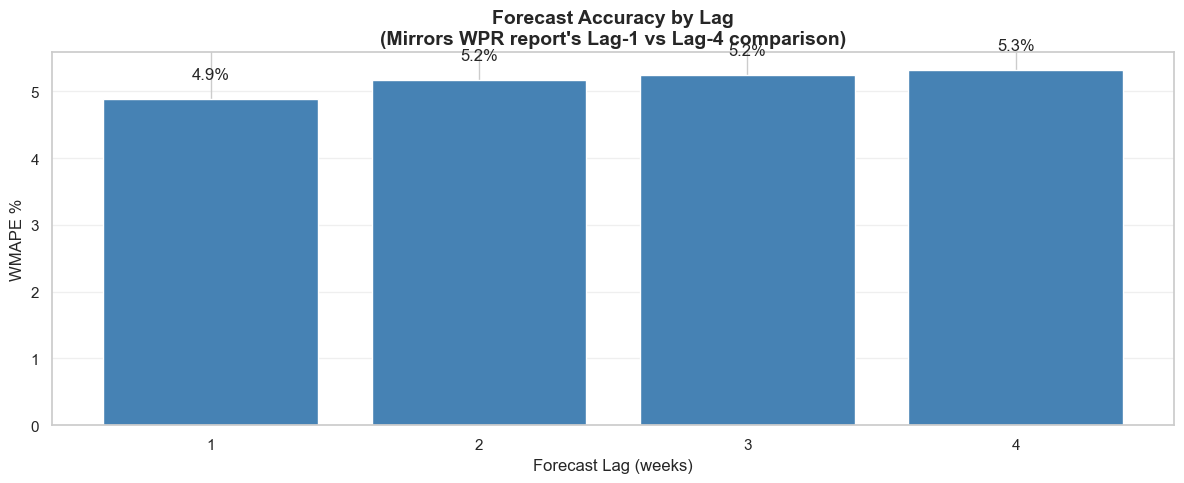

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(lag_table["lag_weeks"].astype(str), lag_table["wmape_pct"], color="steelblue")
for i, row in lag_table.iterrows():
    ax.text(i, row["wmape_pct"] + 0.3, f"{row['wmape_pct']:.1f}%", ha="center")
ax.set_xlabel("Forecast Lag (weeks)")
ax.set_ylabel("WMAPE %")
ax.set_title("Forecast Accuracy by Lag\n(Mirrors WPR report's Lag-1 vs Lag-4 comparison)",
             fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(PRESENTATION_DIR / "06_lag_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Save Prophet forecast for the business notebook
Persist with the column names Notebook 3 expects (`packages_forecast`,
`packages_low`, `packages_high`). Prophet provides the CI bands natively.

In [16]:
prophet_forecast["week_start"] = prophet_forecast["ds"]
prophet_forecast["packages_forecast"] = prophet_forecast["yhat"]
prophet_forecast["packages_low"] = prophet_forecast["yhat_lower"]
prophet_forecast["packages_high"] = prophet_forecast["yhat_upper"]
prophet_forecast[["week_start", "packages_forecast", "packages_low", "packages_high"]].to_parquet(
    DATA_DIR / "network_forecast.parquet", index=False,
)
print("Saved Prophet forecast for business notebook.")

Saved Prophet forecast for business notebook.


## 9. Feature documentation table (for the deck)
Each feature paired with a one-line business justification — useful as a
slide appendix when an interviewer asks "why these features?"

In [17]:
feature_table = get_feature_table(feature_cols)
feature_table

,feature,business_justification
0,lag_1,Last week's volume — strongest single predicto...
1,lag_2,2-week-ago volume — captures very-short-term m...
2,lag_4,4-week-ago volume — captures monthly cycle
3,lag_8,8-week-ago volume — early indicator of trend s...
4,lag_12,12-week-ago (quarterly) volume
5,lag_52,Same week last year — captures annual seasonal...
6,yoy_growth,Year-over-year growth rate — captures structur...
7,year,—
8,month,Month — coarser seasonality
9,quarter,Quarter — quarterly business cycle


## ✅ Done

Notebook 2 produced 3 artifacts in `data/` and 3 charts in `presentation/`.
The forecast parquet is now ready for the business application notebook.

In [18]:
print("=" * 60)
print("✅ Notebook 2 complete")
print("=" * 60)
print("data/         model_scorecard.csv, lag_analysis.csv, network_forecast.parquet")
print("presentation/ 04_feature_importance.png, 05_forecast_vs_actuals.png, 06_lag_analysis.png")
print(f"Best model:   {scorecard.iloc[0]['model']} "
      f"(WMAPE {scorecard.iloc[0]['wmape_pct']:.2f}%, "
      f"Traditional Error {scorecard.iloc[0]['traditional_error_pct']:.2f}%)")

✅ Notebook 2 complete
data/         model_scorecard.csv, lag_analysis.csv, network_forecast.parquet
presentation/ 04_feature_importance.png, 05_forecast_vs_actuals.png, 06_lag_analysis.png
Best model:   LightGBM (WMAPE 1.55%, Traditional Error -0.64%)
